In [3]:
import pandas as pd
from collections import defaultdict

In [4]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# show all columns
pd.set_option("display.max_columns", None)

by .GlobalEnv when processing object ‘.pbd_env’


In [5]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [6]:
%%R

require('tidyverse')
require('DescTools')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: DescTools


In [7]:
df2 = pd.read_csv('atp_matches_2024.csv')

# annotate five-set matches
five_set = ['Us Open','Roland Garros', 'Australian Open', 'Wimbledon']
df2['five_set'] = df2.tourney_name.isin(five_set)

df2

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,five_set
0,2024-0339,Brisbane,Hard,32,A,20240101,300,105777,2.0,NaN,Grigor Dimitrov,R,191.0,BUL,32.6,208029,1.0,NaN,Holger Rune,R,188.0,DEN,20.6,7-6(5) 6-4,3,F,136.0,8.0,2.0,74.0,52.0,40.0,13.0,11.0,3.0,3.0,9.0,3.0,95.0,58.0,44.0,16.0,11.0,8.0,9.0,14.0,2570.0,8.0,3660.0,False
1,2024-0339,Brisbane,Hard,32,A,20240101,299,208029,1.0,NaN,Holger Rune,R,188.0,DEN,20.6,126128,NaN,NaN,Roman Safiullin,R,185.0,RUS,26.4,6-4 7-6(0),3,SF,97.0,7.0,4.0,72.0,48.0,39.0,11.0,11.0,1.0,2.0,5.0,5.0,66.0,35.0,31.0,10.0,11.0,5.0,7.0,8.0,3660.0,39.0,1122.0,False
2,2024-0339,Brisbane,Hard,32,A,20240101,298,105777,2.0,NaN,Grigor Dimitrov,R,191.0,BUL,32.6,111442,NaN,NaN,Jordan Thompson,R,183.0,AUS,29.7,6-3 7-5,3,SF,109.0,10.0,3.0,67.0,45.0,39.0,10.0,11.0,6.0,6.0,5.0,1.0,62.0,39.0,24.0,14.0,10.0,5.0,7.0,14.0,2570.0,55.0,902.0,False
3,2024-0339,Brisbane,Hard,32,A,20240101,297,208029,1.0,NaN,Holger Rune,R,188.0,DEN,20.6,105902,NaN,Q,James Duckworth,R,183.0,AUS,31.9,6-2 7-6(6),3,QF,105.0,13.0,0.0,65.0,36.0,31.0,17.0,10.0,1.0,1.0,5.0,2.0,77.0,51.0,31.0,16.0,10.0,3.0,5.0,8.0,3660.0,116.0,573.0,False
4,2024-0339,Brisbane,Hard,32,A,20240101,296,126128,NaN,NaN,Roman Safiullin,R,185.0,RUS,26.4,208286,NaN,NaN,Matteo Arnaldi,R,185.0,ITA,22.8,7-6(4) 6-2,3,QF,120.0,9.0,3.0,73.0,43.0,36.0,14.0,10.0,2.0,3.0,3.0,2.0,69.0,37.0,27.0,16.0,10.0,5.0,8.0,39.0,1122.0,44.0,1021.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3071,2024-M-DC-2024-WG2-PO-URU-MDA-01,Davis Cup WG2 PO: URU vs MDA,Clay,4,D,20240203,5,212051,NaN,NaN,Joaquin Aguilar Cardozo,U,NaN,URU,18.8,209943,NaN,NaN,Ilya Snitari,R,188.0,MDA,21.8,6-1 6-0,3,RR,77.0,0.0,0.0,36.0,22.0,15.0,10.0,7.0,1.0,1.0,1.0,1.0,61.0,30.0,17.0,7.0,6.0,8.0,14.0,1109.0,8.0,740.0,34.0,False
3072,2024-M-DC-2024-WG2-PO-VIE-RSA-01,Davis Cup WG2 PO: VIE vs RSA,Hard,4,D,20240202,1,122533,NaN,NaN,Nam Hoang Ly,R,175.0,VIE,26.9,202475,NaN,NaN,Philip Henning,R,NaN,RSA,23.2,6-3 6-4,3,RR,131.0,1.0,1.0,86.0,60.0,40.0,13.0,10.0,8.0,9.0,2.0,1.0,56.0,41.0,25.0,6.0,9.0,1.0,4.0,554.0,67.0,748.0,32.0,False
3073,2024-M-DC-2024-WG2-PO-VIE-RSA-01,Davis Cup WG2 PO: VIE vs RSA,Hard,4,D,20240202,2,144748,NaN,NaN,Kris Van Wyk,R,185.0,RSA,27.3,144775,NaN,NaN,Linh Giang Trinh,R,183.0,VIE,26.4,4-6 6-3 4-0,3,RR,131.0,4.0,2.0,76.0,46.0,32.0,10.0,12.0,6.0,11.0,0.0,2.0,71.0,51.0,25.0,7.0,11.0,5.0,12.0,416.0,109.0,NaN,NaN,False
3074,2024-M-DC-2024-WG2-PO-VIE-RSA-01,Davis Cup WG2 PO: VIE vs RSA,Hard,4,D,20240202,4,122533,NaN,NaN,Nam Hoang Ly,R,175.0,VIE,26.9,144748,NaN,NaN,Kris Van Wyk,R,185.0,RSA,27.3,6-4 3-6 6-3,3,RR,159.0,0.0,1.0,84.0,61.0,41.0,13.0,14.0,2.0,5.0,5.0,3.0,86.0,51.0,32.0,17.0,14.0,5.0,9.0,554.0,67.0,416.0,109.0,False


In [8]:
# Load match data
df = pd.read_csv('atp_matches_2023.csv')
df = df.sort_values('tourney_date')

five_set = ['Us Open','Roland Garros', 'Australian Open', 'Wimbledon']
df['five_set'] = df.tourney_name.isin(five_set)


# Initialize Elo ratings
elo_ratings = defaultdict(lambda: 1500)

# Store Elo snapshot *before* each match
elo_snapshots = []

K = 30

def win_prob(rating_i, rating_j):
    return 1 / (1 + 10 ** ((rating_j - rating_i) / 400))

for _, match in df.iterrows():
    winner = match['winner_name']
    loser = match['loser_name']

    rating_winner = elo_ratings[winner]
    rating_loser = elo_ratings[loser]

    # Record pre-match Elo ratings
    elo_snapshots.append({
        'date': match['tourney_date'],
        'surface': match['surface'],
        'tournament': match['tourney_name'],
        'winner': winner,
        'loser': loser,
        'five_set': match['five_set'],
        'winner_elo_before': rating_winner,
        'loser_elo_before': rating_loser
    })

    # Calculate expected outcomes
    expected_win = win_prob(rating_winner, rating_loser)
    expected_loss = 1 - expected_win

    # Update ratings
    elo_ratings[winner] += K * (1 - expected_win)
    elo_ratings[loser] += K * (0 - expected_loss)

# Create DataFrame
elo_df = pd.DataFrame(elo_snapshots)
elo_df

,date,surface,tournament,winner,loser,five_set,winner_elo_before,loser_elo_before
0,20230102,Hard,United Cup,Taylor Fritz,Matteo Berrettini,False,1500.000000,1500.000000
1,20230102,Hard,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,False,1500.000000,1500.000000
2,20230102,Hard,Adelaide 1,Marcos Giron,Richard Gasquet,False,1500.000000,1500.000000
3,20230102,Hard,Adelaide 1,Mackenzie Mcdonald,Daniel Elahi Galan,False,1500.000000,1500.000000
4,20230102,Hard,Adelaide 1,Yoshihito Nishioka,Holger Rune,False,1500.000000,1500.000000
...,...,...,...,...,...,...,...,...
2981,20231127,Hard,NextGen Finals,Hamad Medjedovic,Luca Van Assche,False,1559.394870,1476.388274
2982,20231127,Hard,NextGen Finals,Hamad Medjedovic,Abedallah Shelbayh,False,1570.877850,1447.949709
2983,20231127,Hard,NextGen Finals,Abedallah Shelbayh,Alex Michelsen,False,1438.046036,1489.435844
2984,20231127,Hard,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,False,1464.905294,1455.248672


In [9]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Randomly assign winner to be Player A or B
winner_is_A = np.random.randint(0, 2, size=len(elo_df)) == 1

# Create transformed DataFrame
elo_transformed = pd.DataFrame({
    'date': elo_df['date'],
    'tournament': elo_df['tournament'],
    'surface' : elo_df['surface'],
    'five_set': elo_df['five_set'],
    'player_A_name': np.where(winner_is_A, elo_df['winner'], elo_df['loser']),
    'player_B_name': np.where(winner_is_A, elo_df['loser'], elo_df['winner']),
    
    'player_A_elo_before': np.where(winner_is_A, elo_df['winner_elo_before'], elo_df['loser_elo_before']),
    'player_B_elo_before': np.where(winner_is_A, elo_df['loser_elo_before'], elo_df['winner_elo_before']),
    
    'player_A_win': winner_is_A.astype(int)
})
elo_transformed

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win
0,20230102,United Cup,Hard,False,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0
1,20230102,Adelaide 1,Hard,False,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1
2,20230102,Adelaide 1,Hard,False,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0
3,20230102,Adelaide 1,Hard,False,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0
4,20230102,Adelaide 1,Hard,False,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0
...,...,...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hard,False,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1
2982,20231127,NextGen Finals,Hard,False,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0
2983,20231127,NextGen Finals,Hard,False,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0
2984,20231127,NextGen Finals,Hard,False,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1


In [10]:
elo_transformed['elo_difference'] = elo_transformed['player_A_elo_before'] - elo_transformed ['player_B_elo_before']
elo_transformed

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference
0,20230102,United Cup,Hard,False,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0,0.000000
1,20230102,Adelaide 1,Hard,False,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1,0.000000
2,20230102,Adelaide 1,Hard,False,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0,0.000000
3,20230102,Adelaide 1,Hard,False,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0,0.000000
4,20230102,Adelaide 1,Hard,False,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hard,False,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1,83.006596
2982,20231127,NextGen Finals,Hard,False,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0,-122.928140
2983,20231127,NextGen Finals,Hard,False,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0,51.389809
2984,20231127,NextGen Finals,Hard,False,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1,9.656621


## Ground truth


Attaching package: ‘flexplot’

The following object is masked from ‘package:ggplot2’:

    flip_data



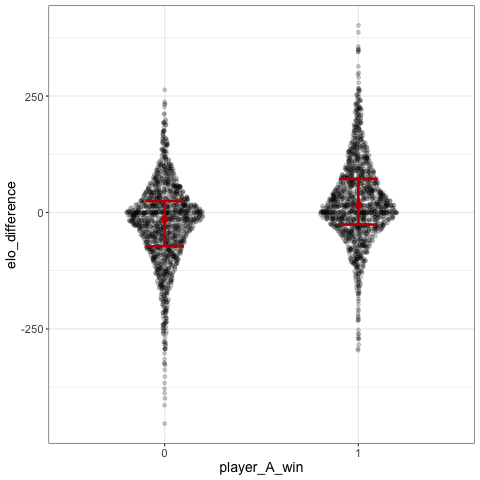

In [11]:
%%R -i elo_transformed

library(flexplot)
flexplot(elo_difference ~ player_A_win, data=elo_transformed)

In [59]:
%%R 

logistic <- glm(player_A_win ~ elo_difference + elo_difference:five_set, data=elo_transformed, family=binomial)
print(summary(logistic))
print(PseudoR2(logistic, which="McFadden"))


Call:
glm(formula = player_A_win ~ elo_difference + elo_difference:five_set, 
    family = binomial, data = elo_transformed)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -0.0222114  0.0380964  -0.583  0.55987    
elo_difference               0.0057762  0.0005125  11.270  < 2e-16 ***
elo_difference:five_setTRUE  0.0041109  0.0012930   3.179  0.00148 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4139.0  on 2985  degrees of freedom
Residual deviance: 3894.6  on 2983  degrees of freedom
AIC: 3900.6

Number of Fisher Scoring iterations: 4

  McFadden 
0.05904692 


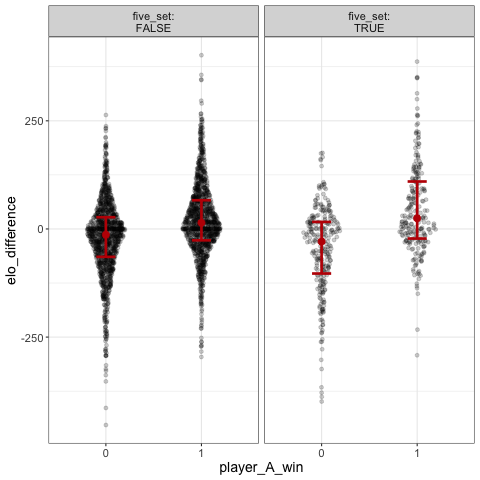

In [11]:
%%R 

flexplot(elo_difference ~ player_A_win | five_set, data=elo_transformed)

In [60]:
%%R 

df <- elo_transformed %>% mutate(
    predict_proba_R = predict(logistic, type="response"),
    predict_R = ifelse(predict_proba_R > .5, 1,0)
) %>% arrange(elo_difference)

df %>% head()

         date         tournament surface five_set player_A_hand player_B_hand
2085 20230807     Canada Masters    Hard    FALSE             L             R
2147 20230814 Cincinnati Masters    Hard    FALSE             R             R
2346 20230828            Us Open    Hard     TRUE             R             R
2359 20230828            Us Open    Hard     TRUE             R             R
2365 20230828            Us Open    Hard     TRUE             R             R
2325 20230828            Us Open    Hard     TRUE             L             R
               player_A_name  player_B_name player_A_elo_before
2085             Ben Shelton Carlos Alcaraz            1410.849
2147             Max Purcell Carlos Alcaraz            1432.600
2346 Bernabe Zapata Miralles Novak Djokovic            1458.761
2359            Lloyd Harris Carlos Alcaraz            1464.366
2365        Alexandre Muller Novak Djokovic            1481.946
2325             Ben Shelton Novak Djokovic            1476.306
     p

## Analyzing residuals

In [13]:
%%R

library(dplyr)

df_filtered <- df %>%
  filter(player_A_win != predict_R) %>%
  arrange(desc(predict_proba_R))

head(df_filtered)

         date    tournament surface five_set      player_A_name
2256 20230828       Us Open    Hard     TRUE        Holger Rune
2328 20230828       Us Open    Hard     TRUE     Frances Tiafoe
2341 20230828       Us Open    Hard     TRUE Stefanos Tsitsipas
1738 20230703     Wimbledon   Grass     TRUE        Casper Ruud
2333 20230828       Us Open    Hard     TRUE         Tommy Paul
2860 20231030 Paris Masters    Hard    FALSE     Carlos Alcaraz
               player_B_name player_A_elo_before player_B_elo_before
2256 Roberto Carballes Baena            1686.954            1511.103
2328             Ben Shelton            1647.789            1473.056
2341        Dominic Stricker            1674.578            1508.547
1738             Liam Broady            1634.402            1472.959
2333             Ben Shelton            1654.008            1495.022
2860         Roman Safiullin            1837.876            1574.445
     player_A_win elo_difference predict_proba_R predict_R
2256      

In [14]:
%%R

library(dplyr)

df_filtered <- df %>%
  filter(player_A_win != predict_R) %>%
  arrange((predict_proba_R))

head(df_filtered)

         date     tournament surface five_set         player_A_name
1409 20230529  Roland Garros    Clay     TRUE   Thiago Seyboth Wild
1514 20230529  Roland Garros    Clay     TRUE       Daniel Altmaier
1941 20230724        Hamburg    Clay    FALSE       Daniel Altmaier
1251 20230508   Rome Masters    Clay    FALSE       Fabian Marozsan
2105 20230807 Canada Masters    Hard    FALSE            Tommy Paul
1621 20230619          Halle   Grass    FALSE Roberto Bautista Agut
       player_B_name player_A_elo_before player_B_elo_before player_A_win
1409 Daniil Medvedev            1500.000            1791.986            1
1514   Jannik Sinner            1458.159            1690.906            1
1941   Andrey Rublev            1446.236            1742.111            1
1251  Carlos Alcaraz            1500.038            1783.473            1
2105  Carlos Alcaraz            1599.816            1871.224            1
1621 Daniil Medvedev            1470.555            1741.957            1
     e

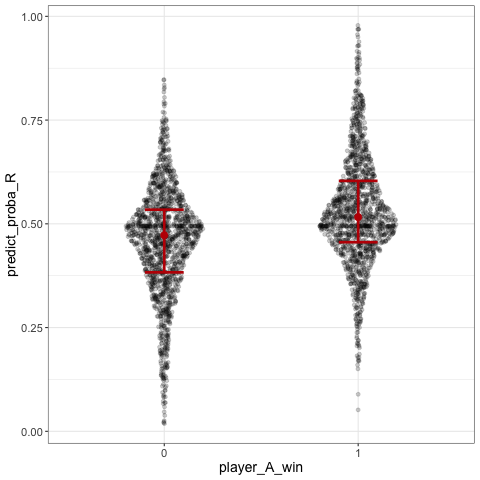

In [15]:
%%R 

flexplot(predict_proba_R ~ player_A_win, data=df, method='lm')

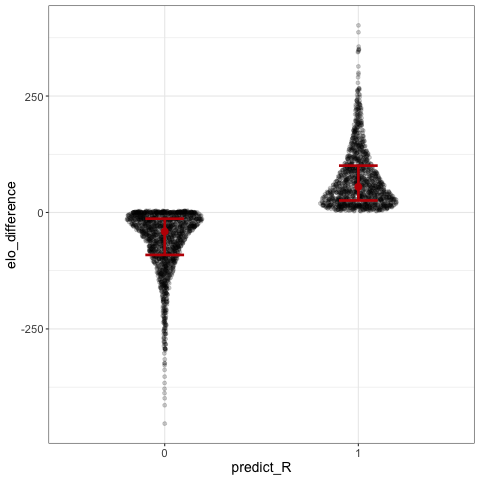

In [16]:
%%R 

flexplot(elo_difference ~ predict_R, data=df)

In [17]:
%%R 

# Create confusion matrix
conf_mat <- table(df$predict_R, df$player_A_win)
print(conf_mat) 

# Extract TP, FP, FN
TP <- conf_mat[2,2]
FP <- conf_mat[2,1]
FN <- conf_mat[1,2]
# Calculate Precision and Recall
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
# Print
cat("Precision:", precision, "\n")
cat("Recall:", recall, "\n")

   
      0   1
  0 979 652
  1 533 822
Precision: 0.6066421 
Recall: 0.5576662 


In [12]:
surface_clustered = pd.read_csv("surface_clusters_2024.csv")

## Trying player clusters

In [13]:
# Rename for merging with player A and player B
cluster_A = surface_clustered.rename(columns={
    'player_name': 'player_A_name',
    'cluster': 'player_A_cluster'
})

cluster_B = surface_clustered.rename(columns={
    'player_name': 'player_B_name',
    'cluster': 'player_B_cluster'
})


In [14]:
# Merge on both player name and surface
elo_transformed = elo_transformed.merge(
    cluster_A[['player_A_name', 'surface', 'player_A_cluster']],
    on=['player_A_name', 'surface'],
    how='left'
)

elo_transformed = elo_transformed.merge(
    cluster_B[['player_B_name', 'surface', 'player_B_cluster']],
    on=['player_B_name', 'surface'],
    how='left'
)


In [15]:
elo_transformed

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,player_A_cluster,player_B_cluster
0,20230102,United Cup,Hard,False,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0,0.000000,0.0,0.0
1,20230102,Adelaide 1,Hard,False,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1,0.000000,0.0,0.0
2,20230102,Adelaide 1,Hard,False,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0,0.000000,1.0,1.0
3,20230102,Adelaide 1,Hard,False,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0,0.000000,1.0,1.0
4,20230102,Adelaide 1,Hard,False,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0,0.000000,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hard,False,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1,83.006596,0.0,1.0
2982,20231127,NextGen Finals,Hard,False,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0,-122.928140,2.0,0.0
2983,20231127,NextGen Finals,Hard,False,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0,51.389809,1.0,2.0
2984,20231127,NextGen Finals,Hard,False,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1,9.656621,1.0,2.0


In [16]:
%%R -i elo_transformed

logistic_new <- glm(player_A_win ~ elo_difference + elo_difference:five_set + player_A_cluster + player_B_cluster, data=elo_transformed, family=binomial)
print(summary(logistic_new))
print(PseudoR2(logistic_new, which="McFadden"))


Call:
glm(formula = player_A_win ~ elo_difference + elo_difference:five_set + 
    player_A_cluster + player_B_cluster, family = binomial, data = elo_transformed)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -0.082165   0.071156  -1.155  0.24821    
elo_difference               0.005625   0.000535  10.514  < 2e-16 ***
player_A_cluster            -0.087778   0.070103  -1.252  0.21052    
player_B_cluster             0.179486   0.069536   2.581  0.00985 ** 
elo_difference:five_setTRUE  0.003980   0.001391   2.862  0.00421 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 3357.3  on 2421  degrees of freedom
Residual deviance: 3142.3  on 2417  degrees of freedom
  (564 observations deleted due to missingness)
AIC: 3152.3

Number of Fisher Scoring iterations: 4

  McFadden 
0.06404678 


In [17]:
%%R 

df_model <- model.frame(logistic_new)

df <- df_model %>%
  mutate(
    predict_proba_R = predict(logistic_new, type = "response"),
    predict_R = ifelse(predict_proba_R > 0.5, 1, 0)
  )


In [18]:
%%R 

# Create confusion matrix
conf_mat <- table(df$predict_R, df$player_A_win)
print(conf_mat) 

# Extract TP, FP, FN
TP <- conf_mat[2,2]
FP <- conf_mat[2,1]
FN <- conf_mat[1,2]
# Calculate Precision and Recall
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
# Print
cat("Precision:", precision, "\n")
cat("Recall:", recall, "\n")

   
      0   1
  0 778 490
  1 446 708
Precision: 0.6135182 
Recall: 0.590985 


In [19]:
%%R

library(dplyr)

df_filtered <- df %>%
  filter(player_A_win != predict_R) %>%
  arrange(desc(predict_proba_R))

head(df_filtered)

     player_A_win elo_difference five_set player_A_cluster player_B_cluster
1738            0       161.4437     TRUE                0                2
2256            0       175.8514     TRUE                0                1
2328            0       174.7331     TRUE                0                0
2341            0       166.0318     TRUE                0                0
1557            0       231.9176    FALSE                1                2
2860            0       263.4314    FALSE                0                0
     predict_proba_R predict_R
1738       0.8614621         1
2256       0.8564839         1
2328       0.8314811         1
2341       0.8194438         1
1557       0.8166097         1
2860       0.8021224         1


In [20]:
%%R

library(dplyr)

df_filtered <- df %>%
  filter(player_A_win != predict_R) %>%
  arrange((predict_proba_R))

head(df_filtered)

     player_A_win elo_difference five_set player_A_cluster player_B_cluster
1409            1      -291.9855     TRUE                1                1
1514            1      -232.7473     TRUE                1                2
2105            1      -271.4087    FALSE                1                0
2088            1      -261.1995    FALSE                1                0
2639            1      -261.1032    FALSE                1                0
1251            1      -283.4351    FALSE                1                1
     predict_proba_R predict_R
1409       0.0575949         0
1514       0.1144038         0
2105       0.1549109         0
2088       0.1625786         0
2639       0.1626524         0
1251       0.1701234         0


In [21]:
%%R
elo_transformed <- elo_transformed %>% drop_na()


In [22]:
%%R
df <- elo_transformed %>% mutate(
    predict_proba_R = predict(logistic_new, type = "response"),
    predict_R = ifelse(predict_proba_R > 0.5, 1, 0)
) %>% arrange(elo_difference)

head(df)


         date         tournament surface five_set           player_A_name
2085 20230807     Canada Masters    Hard    FALSE             Ben Shelton
2147 20230814 Cincinnati Masters    Hard    FALSE             Max Purcell
2346 20230828            Us Open    Hard     TRUE Bernabe Zapata Miralles
2359

 20230828            Us Open    Hard     TRUE            Lloyd Harris
2365 20230828            Us Open    Hard     TRUE        Alexandre Muller
2325 20230828            Us Open    Hard     TRUE             Ben Shelton
      player_B_name player_A_elo_before player_B_elo_before player_A_win
2085 Carlos Alcaraz            1410.849            1864.117            0
2147 Carlos Alcaraz            1432.600            1846.424            0
2346 Novak Djokovic            1458.761            1857.669            0
2359 Carlos Alcaraz            1464.366            1852.335            0
2365 Novak Djokovic            1481.946            1860.412            0
2325 Novak Djokovic            1476.306            1842.450            0
     elo_difference player_A_cluster player_B_cluster predict_proba_R predict_R
2085      -453.2684                0                0      0.06712233         0
2147      -413.8242                0                0      0.08242184         0
2346      -398.9076            

In [23]:
%%R
write.csv(df, "analysis_with_surface_clusters_2024.csv", row.names = FALSE)